In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader
import optuna

c:\Users\User\Downloads\007\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#library installed

In [2]:
#Download Stock Data

In [3]:
ticker = "AAPL"
data = yf.download(ticker, start="2015-01-01", end="2023-01-01")
close_prices = data['Close'].values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices)

[*********************100%***********************]  1 of 1 completed


In [4]:
#Create Sequences (30 Days → Next Day)

In [5]:
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, 30)

In [6]:
#Train / Val / Test Split (70/20/10)

In [7]:
train_size = int(len(X)*0.7)
val_size = int(len(X)*0.2)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

In [8]:
#PyTorch Dataset

In [9]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(StockDataset(X_val, y_val), batch_size=32)
test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=32)

In [10]:
#MODEL A — Simple RNN

In [11]:
#RNN MODEL

In [12]:
class SimpleRNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50):
        super(SimpleRNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

In [13]:
#LSTM Model

In [14]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [15]:
#Training Function (EarlyStopping + ReduceLROnPlateau)

In [19]:
def train_model(model, train_loader, val_loader, lr):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
    
    best_val_loss = np.inf
    patience = 10
    counter = 0
    
    train_losses = []
    val_losses = []
    
    for epoch in range(100):
        model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        
        scheduler.step(val_loss)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            counter += 1
            if counter >= patience:
                print("Early Stopping")
                break
        
        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    model.load_state_dict(torch.load("best_model.pth"))
    return model, train_losses, val_losses

In [20]:
#Optuna Hyperparameter Tunin

In [21]:
def objective(trial):
    hidden_size = trial.suggest_int("hidden_size", 32, 128)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    
    model = LSTMModel(hidden_size=hidden_size)
    model, _, val_losses = train_model(model, train_loader, val_loader, lr)
    
    return min(val_losses)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print("Best Params:", study.best_params)

[I 2026-02-25 14:54:56,453] A new study created in memory with name: no-name-61d2fd44-2229-4cdd-a205-3900d6dbb731
C:\Users\User\AppData\Local\Temp\ipykernel_3896\1911397367.py:3: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)


Epoch 1 | Train Loss: 0.011005 | Val Loss: 0.212495
Epoch 2 | Train Loss: 0.002500 | Val Loss: 0.131217
Epoch 3 | Train Loss: 0.000229 | Val Loss: 0.016382
Epoch 4 | Train Loss: 0.000190 | Val Loss: 0.007057
Epoch 5 | Train Loss: 0.000175 | Val Loss: 0.006156
Epoch 6 | Train Loss: 0.000176 | Val Loss: 0.007504
Epoch 7 | Train Loss: 0.000178 | Val Loss: 0.006914
Epoch 8 | Train Loss: 0.000162 | Val Loss: 0.008596
Epoch 9 | Train Loss: 0.000168 | Val Loss: 0.006805
Epoch 10 | Train Loss: 0.000188 | Val Loss: 0.006323
Epoch 11 | Train Loss: 0.000157 | Val Loss: 0.010493
Epoch 12 | Train Loss: 0.000144 | Val Loss: 0.003537
Epoch 13 | Train Loss: 0.000144 | Val Loss: 0.010301
Epoch 14 | Train Loss: 0.000139 | Val Loss: 0.008144
Epoch 15 | Train Loss: 0.000132 | Val Loss: 0.010361
Epoch 16 | Train Loss: 0.000126 | Val Loss: 0.006910
Epoch 17 | Train Loss: 0.000127 | Val Loss: 0.008404
Epoch 18 | Train Loss: 0.000137 | Val Loss: 0.011781
Epoch 19 | Train Loss: 0.000119 | Val Loss: 0.005276
Ep

[I 2026-02-25 14:55:06,419] Trial 0 finished with value: 0.003537066681579185 and parameters: {'hidden_size': 110, 'lr': 0.0004042788656735136}. Best is trial 0 with value: 0.003537066681579185.


Early Stopping
Epoch 1 | Train Loss: 0.011551 | Val Loss: 0.324866
Epoch 2 | Train Loss: 0.009235 | Val Loss: 0.221997
Epoch 3 | Train Loss: 0.003908 | Val Loss: 0.015740
Epoch 4 | Train Loss: 0.000255 | Val Loss: 0.002024
Epoch 5 | Train Loss: 0.000175 | Val Loss: 0.002010
Epoch 6 | Train Loss: 0.000170 | Val Loss: 0.002208
Epoch 7 | Train Loss: 0.000173 | Val Loss: 0.002139
Epoch 8 | Train Loss: 0.000187 | Val Loss: 0.002368
Epoch 9 | Train Loss: 0.000169 | Val Loss: 0.001722
Epoch 10 | Train Loss: 0.000201 | Val Loss: 0.001944
Epoch 11 | Train Loss: 0.000166 | Val Loss: 0.001538
Epoch 12 | Train Loss: 0.000170 | Val Loss: 0.001439
Epoch 13 | Train Loss: 0.000168 | Val Loss: 0.001384
Epoch 14 | Train Loss: 0.000173 | Val Loss: 0.001308
Epoch 15 | Train Loss: 0.000158 | Val Loss: 0.001343
Epoch 16 | Train Loss: 0.000142 | Val Loss: 0.001717
Epoch 17 | Train Loss: 0.000146 | Val Loss: 0.001194
Epoch 18 | Train Loss: 0.000153 | Val Loss: 0.001568
Epoch 19 | Train Loss: 0.000135 | Val Lo

[I 2026-02-25 14:55:14,866] Trial 1 finished with value: 0.001006220183066594 and parameters: {'hidden_size': 46, 'lr': 0.0003206237440596353}. Best is trial 1 with value: 0.001006220183066594.


...

Early Stopping
Epoch 1 | Train Loss: 0.005692 | Val Loss: 0.005947
Epoch 2 | Train Loss: 0.000243 | Val Loss: 0.014075
Epoch 3 | Train Loss: 0.000148 | Val Loss: 0.013561
Epoch 4 | Train Loss: 0.000169 | Val Loss: 0.005145
Epoch 5 | Train Loss: 0.000170 | Val Loss: 0.010802
Epoch 6 | Train Loss: 0.000141 | Val Loss: 0.004517
Epoch 7 | Train Loss: 0.000132 | Val Loss: 0.007944
Epoch 8 | Train Loss: 0.000125 | Val Loss: 0.004051
Epoch 9 | Train Loss: 0.000120 | Val Loss: 0.010508
Epoch 10 | Train Loss: 0.000120 | Val Loss: 0.007105
Epoch 11 | Train Loss: 0.000125 | Val Loss: 0.010617
Epoch 12 | Train Loss: 0.000135 | Val Loss: 0.003892
Epoch 13 | Train Loss: 0.000113 | Val Loss: 0.003287
Epoch 14 | Train Loss: 0.000100 | Val Loss: 0.003695
Epoch 15 | Train Loss: 0.000107 | Val Loss: 0.002965
Epoch 16 | Train Loss: 0.000099 | Val Loss: 0.001749
Epoch 17 | Train Loss: 0.000093 | Val Loss: 0.002258
Epoch 18 | Train Loss: 0.000088 | Val Loss: 0.002778
Epoch 19 | Train Loss: 0.000084 | Val Lo

[I 2026-02-25 14:56:42,808] Trial 8 finished with value: 0.0006059691345748993 and parameters: {'hidden_size': 125, 'lr': 0.0010672394667226017}. Best is trial 5 with value: 0.00032913100753481.


Early Stopping
Epoch 1 | Train Loss: 0.018071 | Val Loss: 0.332806
Epoch 2 | Train Loss: 0.007279 | Val Loss: 0.185028
Epoch 3 | Train Loss: 0.001902 | Val Loss: 0.194339
Epoch 4 | Train Loss: 0.000783 | Val Loss: 0.176021
Epoch 5 | Train Loss: 0.000338 | Val Loss: 0.085467
Epoch 6 | Train Loss: 0.000218 | Val Loss: 0.013820
Epoch 7 | Train Loss: 0.000154 | Val Loss: 0.002607
Epoch 8 | Train Loss: 0.000144 | Val Loss: 0.000905
Epoch 9 | Train Loss: 0.000136 | Val Loss: 0.000905
Epoch 10 | Train Loss: 0.000134 | Val Loss: 0.000957
Epoch 11 | Train Loss: 0.000134 | Val Loss: 0.000817
Epoch 12 | Train Loss: 0.000146 | Val Loss: 0.001584
Epoch 13 | Train Loss: 0.000127 | Val Loss: 0.001553
Epoch 14 | Train Loss: 0.000119 | Val Loss: 0.002688
Epoch 15 | Train Loss: 0.000131 | Val Loss: 0.001430
Epoch 16 | Train Loss: 0.000133 | Val Loss: 0.004161
Epoch 17 | Train Loss: 0.000129 | Val Loss: 0.001618
Epoch 18 | Train Loss: 0.000111 | Val Loss: 0.001436
Epoch 19 | Train Loss: 0.000107 | Val Lo

[I 2026-02-25 14:56:50,776] Trial 9 finished with value: 0.0008166121641317239 and parameters: {'hidden_size': 108, 'lr': 0.0005751903776182945}. Best is trial 5 with value: 0.00032913100753481.


Early Stopping
Best Params: {'hidden_size': 47, 'lr': 0.0060446179107124885}


In [22]:
#train final model

rnn_model = SimpleRNNModel(hidden_size=50)
rnn_model, rnn_train_loss, rnn_val_loss = train_model(rnn_model, train_loader, val_loader, lr=0.001)

lstm_model = LSTMModel(hidden_size=50)
lstm_model, lstm_train_loss, lstm_val_loss = train_model(lstm_model, train_loader, val_loader, lr=0.001)

Epoch 1 | Train Loss: 0.009013 | Val Loss: 0.038539
Epoch 2 | Train Loss: 0.000202 | Val Loss: 0.002393
Epoch 3 | Train Loss: 0.000084 | Val Loss: 0.001943
Epoch 4 | Train Loss: 0.000076 | Val Loss: 0.002258
Epoch 5 | Train Loss: 0.000094 | Val Loss: 0.001769
Epoch 6 | Train Loss: 0.000080 | Val Loss: 0.000857
Epoch 7 | Train Loss: 0.000076 | Val Loss: 0.002876
Epoch 8 | Train Loss: 0.000084 | Val Loss: 0.001373
Epoch 9 | Train Loss: 0.000075 | Val Loss: 0.000917
Epoch 10 | Train Loss: 0.000072 | Val Loss: 0.001381
Epoch 11 | Train Loss: 0.000074 | Val Loss: 0.001475
Epoch 12 | Train Loss: 0.000088 | Val Loss: 0.000992
Epoch 13 | Train Loss: 0.000055 | Val Loss: 0.000865
Epoch 14 | Train Loss: 0.000064 | Val Loss: 0.001111
Epoch 15 | Train Loss: 0.000059 | Val Loss: 0.001484
Early Stopping
Epoch 1 | Train Loss: 0.025729 | Val Loss: 0.330231
Epoch 2 | Train Loss: 0.007989 | Val Loss: 0.075468
Epoch 3 | Train Loss: 0.001288 | Val Loss: 0.007367
Epoch 4 | Train Loss: 0.000357 | Val Loss: 

In [23]:
#Evaluation

In [24]:
def evaluate(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    preds = []
    actual = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds.extend(outputs.cpu().numpy())
            actual.extend(y_batch.numpy())
    
    preds = scaler.inverse_transform(preds)
    actual = scaler.inverse_transform(actual)
    
    mse = mean_squared_error(actual, preds)
    mae = mean_absolute_error(actual, preds)
    
    return mse, mae, actual, preds

rnn_mse, rnn_mae, rnn_actual, rnn_preds = evaluate(rnn_model, test_loader)
lstm_mse, lstm_mae, lstm_actual, lstm_preds = evaluate(lstm_model, test_loader)

print("RNN MSE:", rnn_mse, "MAE:", rnn_mae)
print("LSTM MSE:", lstm_mse, "MAE:", lstm_mae)

RNN MSE: 30.795356837748823 MAE: 4.517206957698681
LSTM MSE: 30.311896637481606 MAE: 4.594290485400605


In [25]:
#loss surves 

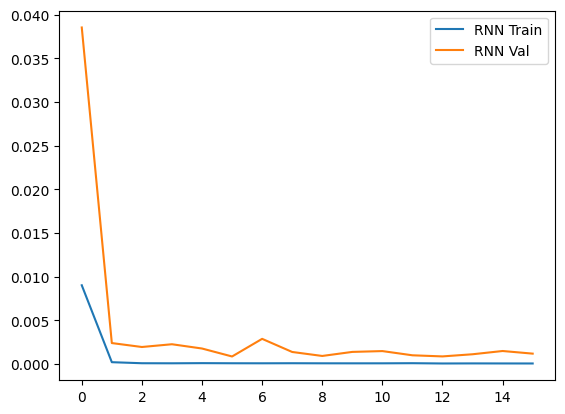

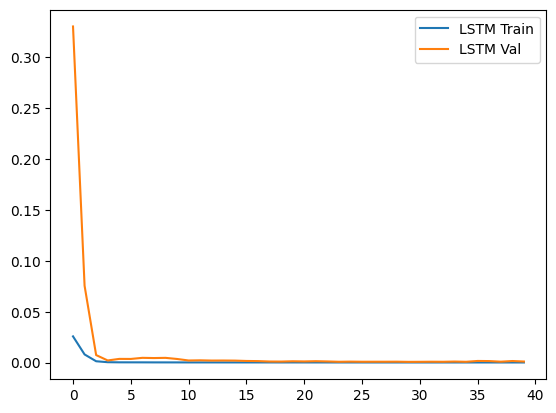

In [26]:
plt.plot(rnn_train_loss, label="RNN Train")
plt.plot(rnn_val_loss, label="RNN Val")
plt.legend()
plt.show()

plt.plot(lstm_train_loss, label="LSTM Train")
plt.plot(lstm_val_loss, label="LSTM Val")
plt.legend()
plt.show()

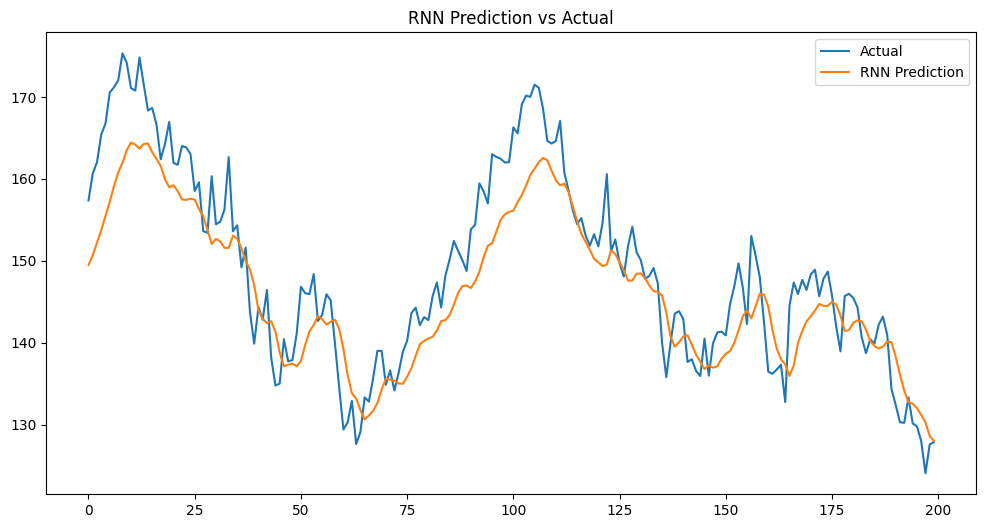

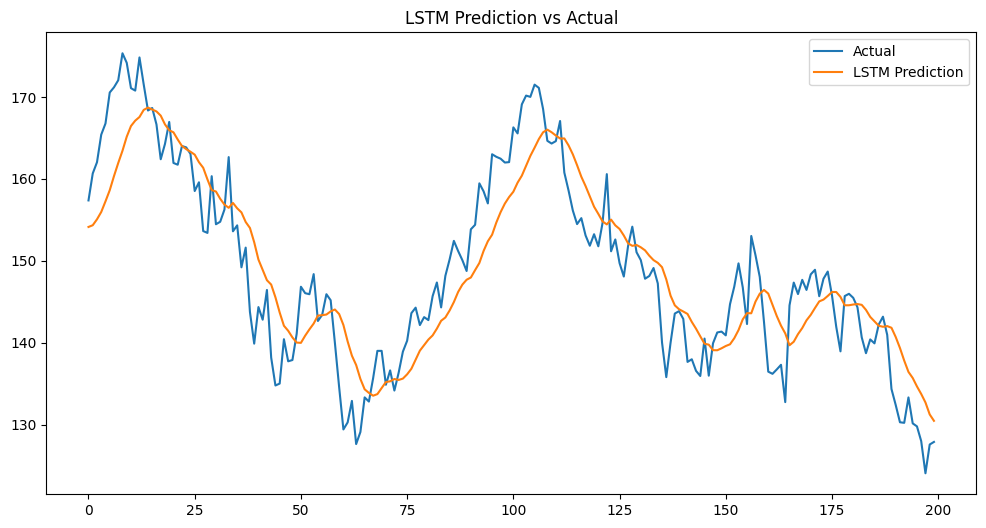

In [27]:
plt.figure(figsize=(12,6))
plt.plot(rnn_actual, label="Actual")
plt.plot(rnn_preds, label="RNN Prediction")
plt.legend()
plt.title("RNN Prediction vs Actual")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(lstm_actual, label="Actual")
plt.plot(lstm_preds, label="LSTM Prediction")
plt.legend()
plt.title("LSTM Prediction vs Actual")
plt.show()